In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression


: 

In [ ]:
df = pd.read_csv('bitcoin (2).csv')
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [3]:
df.shape

(7379677, 6)

In [4]:
df.describe()

,Timestamp,Open,High,Low,Close,Volume
count,7.379677e+06,7.379677e+06,7.379677e+06,7.379677e+06,7.379677e+06,7.379677e+06
mean,1.546806e+09,2.182277e+04,2.183052e+04,2.181482e+04,2.182278e+04,5.099369e+00
std,1.278265e+08,3.044007e+04,3.044828e+04,3.043176e+04,3.044008e+04,2.197989e+01
min,1.325412e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,1.436107e+09,4.463800e+02,4.465700e+02,4.461400e+02,4.463600e+02,2.000000e-02
50%,1.546802e+09,7.380010e+03,7.385290e+03,7.375220e+03,7.380000e+03,4.477050e-01
75%,1.657497e+09,3.271336e+04,3.274036e+04,3.268562e+04,3.271365e+04,2.875794e+00
max,1.768262e+09,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7379677 entries, 0 to 7379676
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 337.8 MB


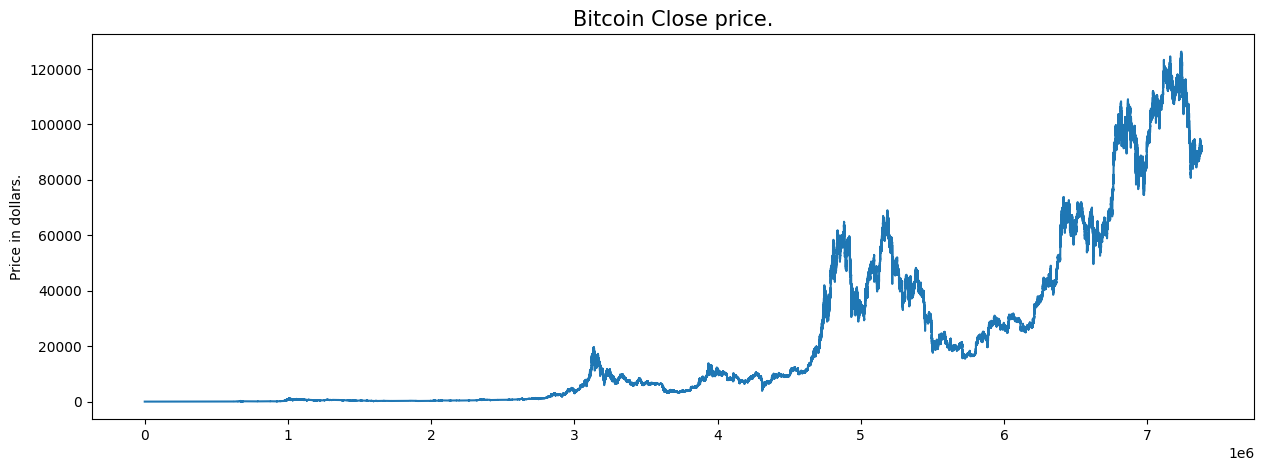

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(df['Close'])
plt.title('Bitcoin Close price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

In [7]:
df.isnull().sum()

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

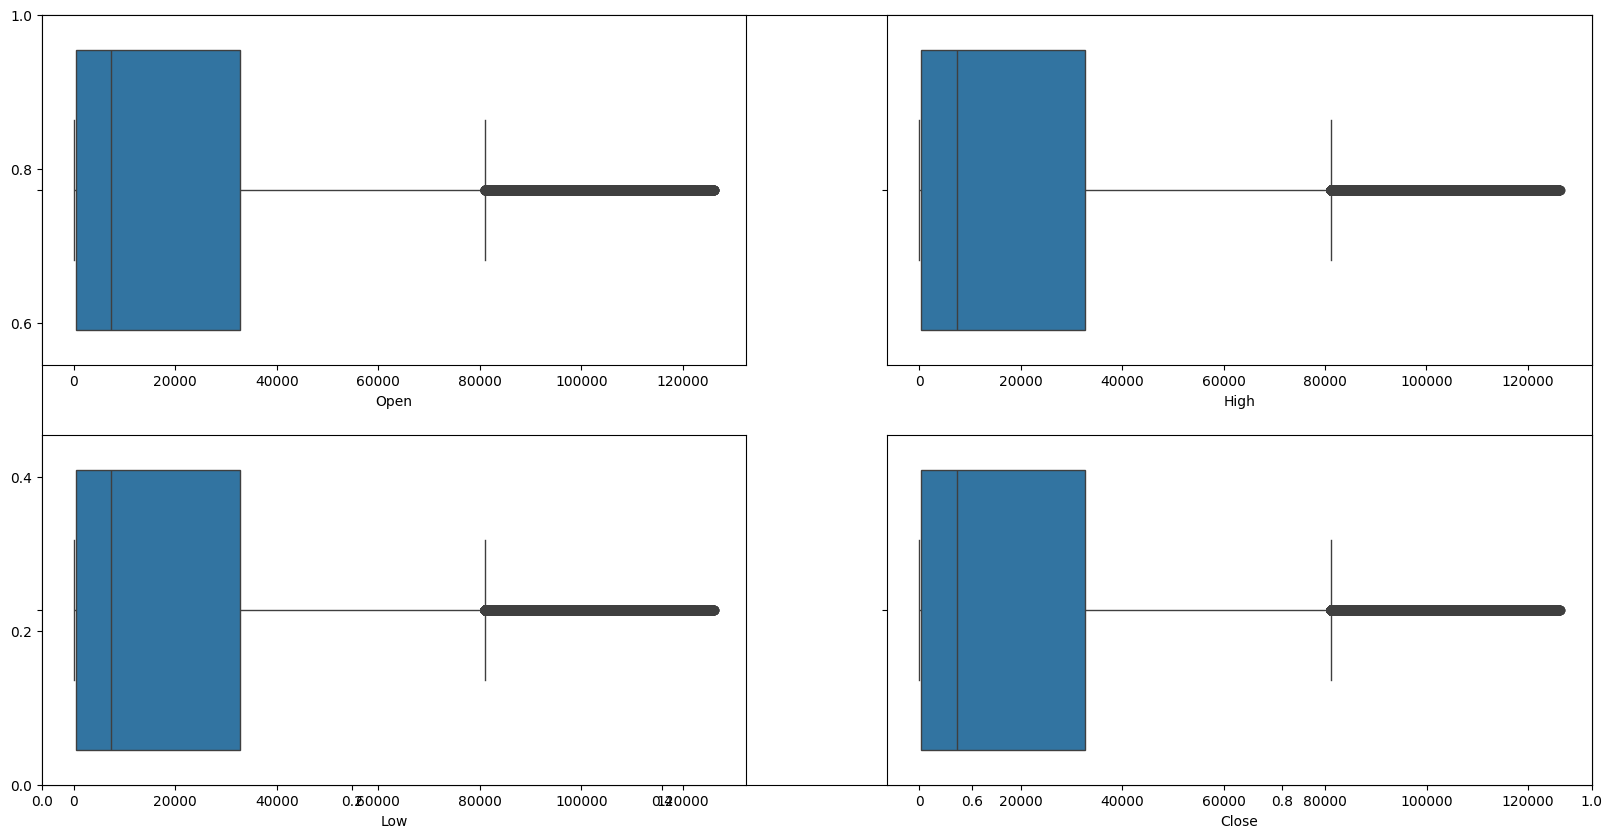

In [8]:
features = ['Open', 'High', 'Low', 'Close']

plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,2,i+1)
  sn.boxplot(df[col], orient='h')
plt.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Timestamp'], errors='coerce')

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day


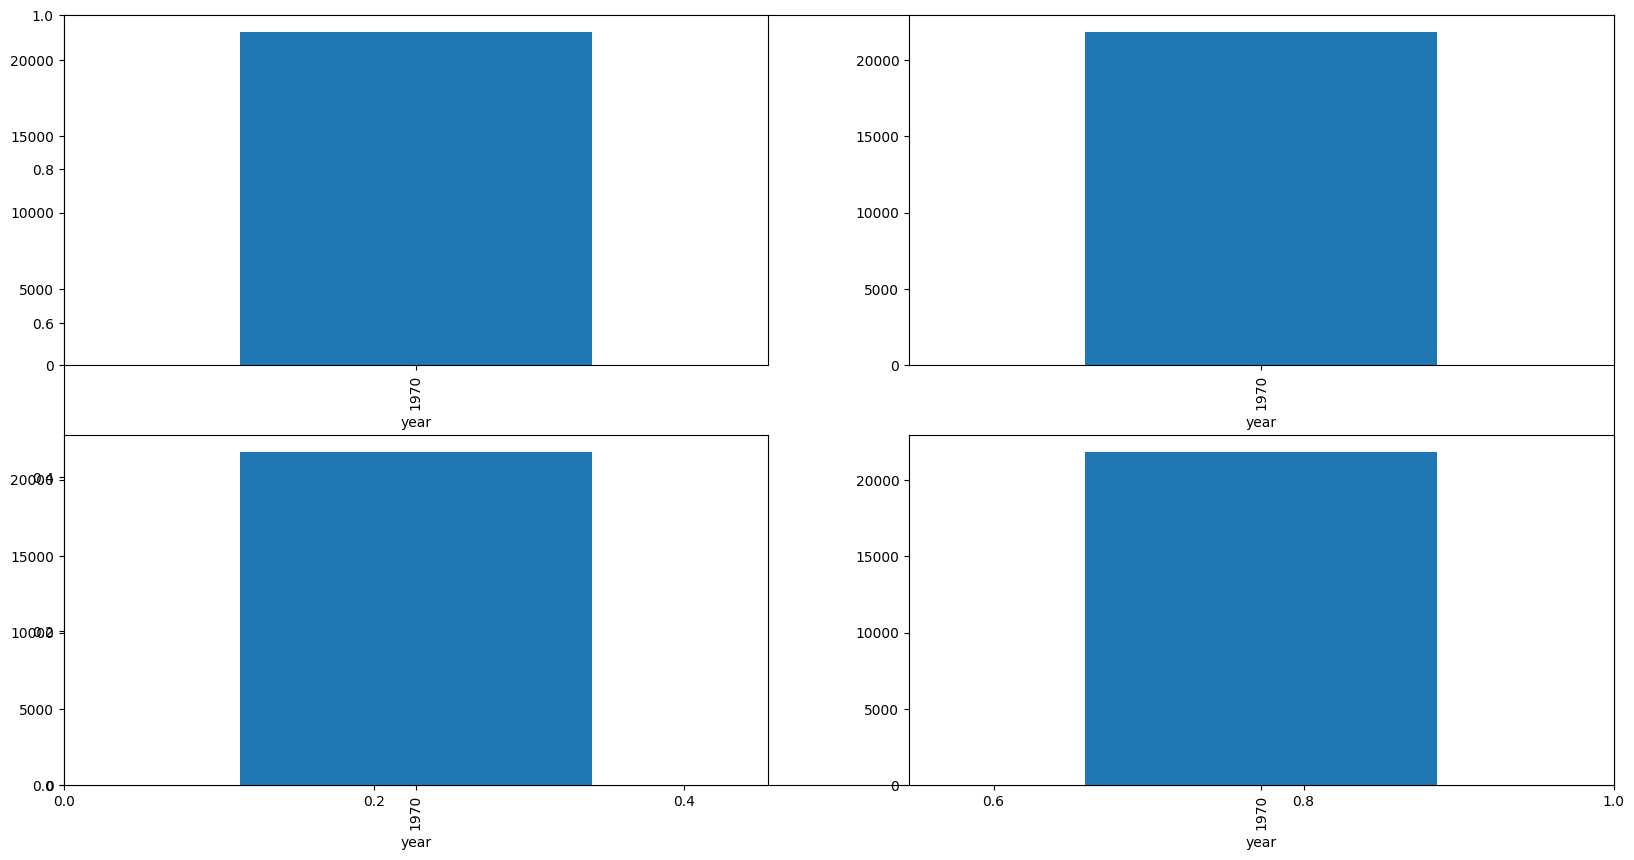

In [10]:
data_grouped = df.groupby('year').mean()
plt.subplots(figsize=(20,10))
for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

In [11]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()


,Timestamp,Open,High,Low,Close,Volume,Date,year,month,day,is_quarter_end
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412060,1970,1,1,0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412120,1970,1,1,0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412180,1970,1,1,0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412240,1970,1,1,0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412300,1970,1,1,0


In [12]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,year,month,day,is_quarter_end
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412060,1970,1,1,0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412120,1970,1,1,0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412180,1970,1,1,0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412240,1970,1,1,0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,1970-01-01 00:00:01.325412300,1970,1,1,0


In [13]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

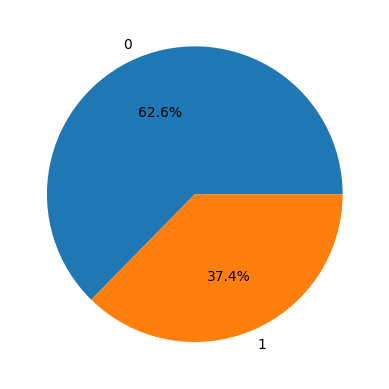

In [14]:
plt.pie(df['target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

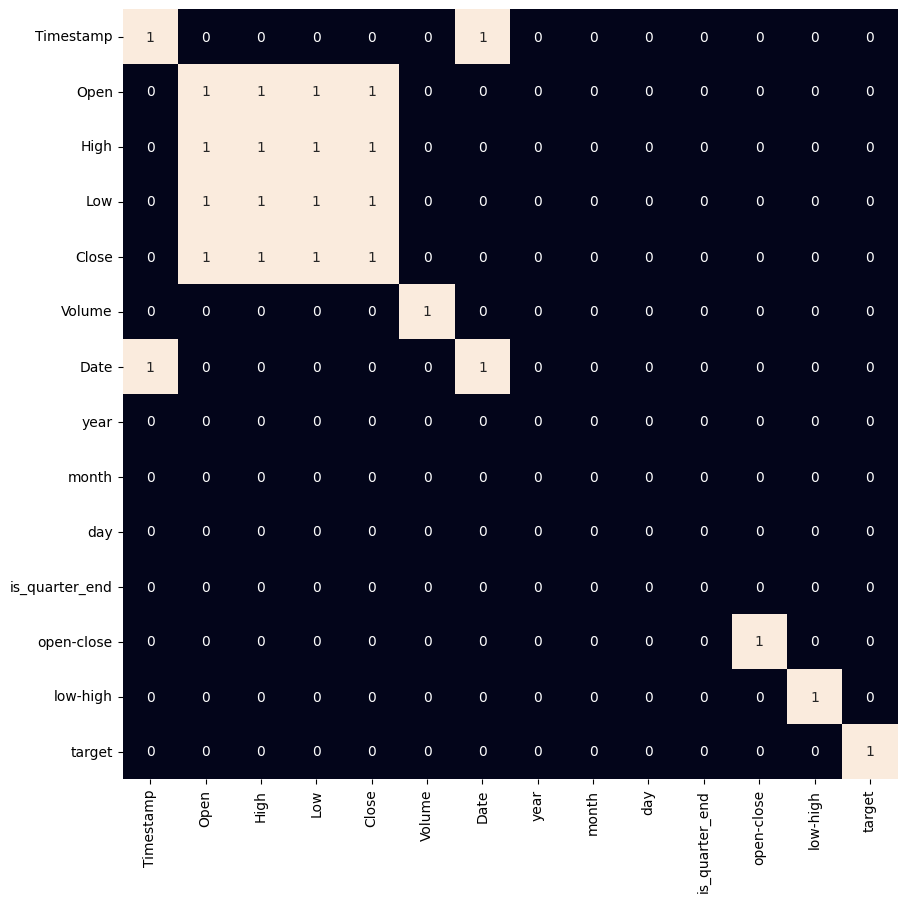

In [15]:
plt.figure(figsize=(10, 10))

sn.heatmap(df.corr() > 0.9, annot=True, cbar=False)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

X = df[['open-close', 'low-high', 'is_quarter_end']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)



In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
data=pd.concat([X,y],axis=1)
data

,open-close,low-high,is_quarter_end,target
0,0.0,0.0,0,0
1,0.0,0.0,0,0
2,0.0,0.0,0,0
3,0.0,0.0,0,0
4,0.0,0.0,0,0
...,...,...,...,...
7379672,-8.0,-9.0,0,0
7379673,5.0,-5.0,0,1
7379674,-4.0,-5.0,0,1
7379675,-14.0,-14.0,0,1


In [19]:
from sklearn.linear_model import LogisticRegression # only change linearRegrassion and put another operation name 
lr= LogisticRegression(max_iter=1000)

In [20]:
lr.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred=lr.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


print("Logistic Regression Accuracy : ", accuracy_score(y_test ,y_pred))
print('\n Classification Report:\n',classification_report(y_test ,y_pred))
print('\n Confusion Matrix:\n',confusion_matrix(y_test ,y_pred))

Logistic Regression Accuracy :  0.6274576494735092

 Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.97      0.77   1388432
           1       0.50      0.05      0.09    825472

    accuracy                           0.63   2213904
   macro avg       0.57      0.51      0.43   2213904
weighted avg       0.58      0.63      0.52   2213904


 Confusion Matrix:
 [[1346414   42018]
 [ 782755   42717]]


In [23]:
data.iloc[-1]

open-close        0.0
low-high         -1.0
is_quarter_end    0.0
target            0.0
Name: 7379676, dtype: float64

In [24]:
cus_input = np.array([[32.529999,-43.752014,1]])

result =lr.predict(cus_input)
print(result)

[0]


c:\Users\Rutuja\OneDrive\Desktop\Internship_project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [25]:
prediction=int(round(result[0]))
prediction

0

In [26]:
def BPrice_predictor():
    open_close = float(input("Enter Open - Close value: "))
    low_high = float(input("Enter Low - High value: "))
    is_quarter_end = int(input("Is it quarter end? (1 = Yes, 0 = No): "))

    # Order MUST match training data
    cus_input = np.array([[open_close, low_high, is_quarter_end]])

    # Apply same scaler used during training
    cus_input_scaled = scaler.transform(cus_input)

    # Predict
    result = lr.predict(cus_input_scaled)
    prediction = int(result[0])

    if prediction == 1:
        print("📈 Bitcoin price will GO UP")
    else:
        print("📉 Bitcoin price will GO DOWN")


In [27]:
BPrice_predictor()


📉 Bitcoin price will GO DOWN


c:\Users\Rutuja\OneDrive\Desktop\Internship_project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Rutuja\OneDrive\Desktop\Internship_project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [30]:
import joblib

In [31]:
joblib.dump(lr, 'bitcoin_price_prediction.pkl')

['bitcoin_price_prediction.pkl']